Guardado wimp_wind_2.png y wimp_wind_2.pdf


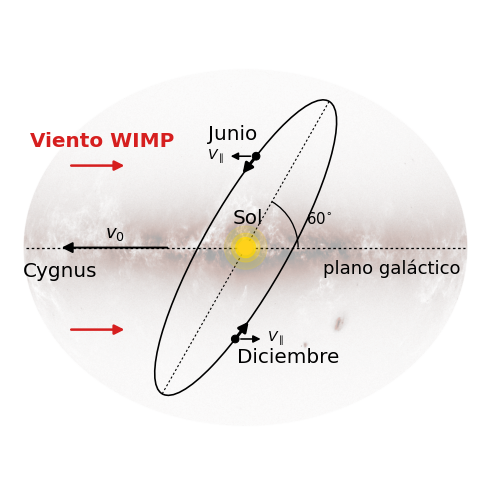

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse, FancyArrowPatch, Arc
from matplotlib.collections import LineCollection
import matplotlib.image as mpimg

# ---------------------------------------------------------------------------
# Figura y fondo (halo galactico)
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 7))
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect("equal")
ax.axis("off")

bg_img = mpimg.imread("fondogal.png")
ax.imshow(bg_img, extent=[-10, 10, -10, 10], origin="upper",
          zorder=0, aspect="auto",alpha=0.8)
# ---------------------------------------------------------------------------
# Sol
# ---------------------------------------------------------------------------
sun_x, sun_y = 0.0, 0.0
# resplandor
for r, a in [(0.9, 0.15), (0.6, 0.3), (0.42, 0.7)]:
    ax.add_patch(plt.Circle((sun_x, sun_y), r, color="gold", alpha=a, zorder=4))
ax.add_patch(plt.Circle((sun_x, sun_y), 0.30, color="#FFD21A", zorder=5))
ax.text(sun_x + 0.1, sun_y + 1.00, "Sol", fontsize=20, ha="center", zorder=6)

# ---------------------------------------------------------------------------
# Plano galactico + eje hacia Cygnus (v0 ~ 220 km/s)
# ---------------------------------------------------------------------------
# eje horizontal punteado (plano galactico)
ax.plot([-9.2, 9.2], [0, 0], ls=(0, (2, 2)), color="black", lw=1.3, zorder=3)
ax.text(3.24, -1.05, "plano galáctico", fontsize=18, ha="left", zorder=6)

# flecha de v0 hacia Cygnus (a la izquierda)
ax.add_patch(FancyArrowPatch(
    (-3.2, 0), (-7.8, 0), arrowstyle="-|>", mutation_scale=22,
    color="black", lw=2, zorder=6))
ax.text(-5.5, 0.45, r"$v_0$", fontsize=18, ha="center", zorder=6)
ax.text(-7.79, -1.2, "Cygnus", fontsize=20, ha="center", zorder=6)

# ---------------------------------------------------------------------------
# Viento de WIMPs (flechas azules apuntando a la derecha = sentido opuesto a v0)
# ---------------------------------------------------------------------------
ax.text(-6, 4.2, "Viento WIMP", fontsize=20, fontweight="bold",
        color="#d61f1f", ha="center", zorder=6)
for (x0, y0) in [(-7.4, 3.4), (-7.4, -3.4)]:
    ax.add_patch(FancyArrowPatch(
        (x0, y0), (x0 + 2.4, y0), arrowstyle="-|>", mutation_scale=20,
        color="#d61f1f", lw=2.5, zorder=6))

# ---------------------------------------------------------------------------
# Orbita terrestre: elipse inclinada 60 deg respecto al plano galactico
# ---------------------------------------------------------------------------
tilt = 60.0  # grados respecto al eje horizontal (plano galactico)
# Elipse vista en perspectiva: eje mayor largo, eje menor corto, rotada 60 deg
a_orb, b_orb = 7.0, 1.75  # semiejes aparentes
orbit = Ellipse((0, 0), 2 * a_orb, 2 * b_orb, angle=tilt,
                fill=False, edgecolor="black", lw=1.6, zorder=4)
ax.add_patch(orbit)

# linea punteada del eje mayor de la orbita (para ver la inclinacion)
th = np.deg2rad(tilt)
ax.plot([-a_orb * np.cos(th), a_orb * np.cos(th)],
        [-a_orb * np.sin(th), a_orb * np.sin(th)],
        ls=(0, (2, 2)), color="black", lw=1.1, zorder=3)

# Arco que marca los 60 grados entre el plano galactico y el eje de la orbita
arc = Arc((0, 0), 4.4, 4.4, angle=0, theta1=0, theta2=tilt,
          color="black", lw=1.3, zorder=5)
ax.add_patch(arc)
ax.text(2.55, 1.0, r"$60^{\circ}$", fontsize=15, ha="left", zorder=6)

# ---------------------------------------------------------------------------
# Posiciones de la Tierra en Junio y Diciembre sobre la orbita
# ---------------------------------------------------------------------------
def orbit_point(t_deg):
    """Punto sobre la elipse rotada, parametro t en grados."""
    t = np.deg2rad(t_deg)
    x = a_orb * np.cos(t)
    y = b_orb * np.sin(t)
    # rotacion por el tilt
    xr = x * np.cos(th) - y * np.sin(th)
    yr = x * np.sin(th) + y * np.cos(th)
    return xr, yr

# Junio arriba-derecha, Diciembre abajo-izquierda (extremos del eje mayor)
jun_x, jun_y = orbit_point(60)      # un extremo
dec_x, dec_y = orbit_point(240)    # extremo opuesto

# Tierra (puntos negros)
ax.add_patch(plt.Circle((jun_x, jun_y), 0.16, color="black", zorder=7))
ax.add_patch(plt.Circle((dec_x, dec_y), 0.16, color="black", zorder=7))
ax.text(jun_x - 1.0, jun_y + 0.7, "Junio", fontsize=20, ha="center", zorder=7)
ax.text(dec_x + 2.2, dec_y - 0.95, "Diciembre", fontsize=20, ha="center", zorder=7)

# Flechas de velocidad orbital (tangentes a la orbita) en cada posicion
def orbit_tangent(t_deg, scale=1.0):
    t = np.deg2rad(t_deg)
    dx = -a_orb * np.sin(t)
    dy = b_orb * np.cos(t)
    dxr = dx * np.cos(th) - dy * np.sin(th)
    dyr = dx * np.sin(th) + dy * np.cos(th)
    n = np.hypot(dxr, dyr)
    return dxr / n * scale, dyr / n * scale

# Junio: la Tierra se mueve contra el viento (V|| reduce velocidad relativa)
tjx, tjy = orbit_tangent(60, 1.0)
ax.add_patch(FancyArrowPatch(
    (jun_x, jun_y), (jun_x + tjx, jun_y + tjy), arrowstyle="-|>",
    mutation_scale=20, color="black", lw=3, zorder=7))
# Diciembre
tdx, tdy = orbit_tangent(240, 1.0)
ax.add_patch(FancyArrowPatch(
    (dec_x, dec_y), (dec_x + tdx, dec_y + tdy), arrowstyle="-|>",
    mutation_scale=20, color="black", lw=3, zorder=7))

# Componente V|| (proyeccion horizontal de la velocidad, a lo largo de v0)
# Junio: flecha horizontal a la izquierda (se suma/resta segun convencion)
ax.add_patch(FancyArrowPatch(
    (jun_x - 0.15, jun_y), (jun_x - 1.15, jun_y), arrowstyle="-|>",
    mutation_scale=15, color="black", lw=1.6, zorder=7))
ax.text(jun_x - 1.35, jun_y + 0.02, r"$V_{\parallel}$", fontsize=14,
        ha="right", va="center", zorder=7)
# Diciembre: flecha horizontal a la derecha
ax.add_patch(FancyArrowPatch(
    (dec_x + 0.15, dec_y), (dec_x + 1.15, dec_y), arrowstyle="-|>",
    mutation_scale=15, color="black", lw=1.6, zorder=7))
ax.text(dec_x + 1.35, dec_y + 0.02, r"$V_{\parallel}$", fontsize=14,
        ha="left", va="center", zorder=7)

plt.tight_layout()
plt.savefig("wimp_wind_2.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.savefig("wimp_wind_2.pdf", bbox_inches="tight",
            facecolor="white")
print("Guardado wimp_wind_2.png y wimp_wind_2.pdf")
